In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

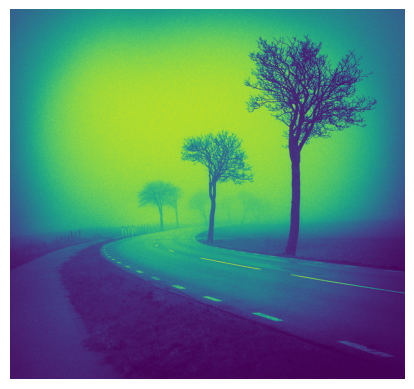

In [3]:
img = cv2.imread('anh_cay_coi.jpg',0)
plt.imshow(img)
plt.axis('off')
plt.show()

## Sobel

In [4]:
def sobel_filter(image):
    kernel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])
    
    kernel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])
    
    height, width = image.shape
    
    # Khởi tạo output
    sobel_x = np.zeros_like(image, dtype=np.float64)
    sobel_y = np.zeros_like(image, dtype=np.float64)
    
    # Padding
    padded = np.pad(image, pad_width=1, mode='edge')
    
    # Convolution thủ công
    for i in range(height):
        for j in range(width):
            region = padded[i:i+3, j:j+3]
            sobel_x[i, j] = np.sum(region * kernel_x)
            sobel_y[i, j] = np.sum(region * kernel_y)
    
    # Tính magnitude
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    
    # Normalize về 0-255
    sobel_combined = np.clip(sobel_combined, 0, 255)
    
    return np.uint8(sobel_combined)

## Laplacian

In [5]:
def laplacian_filter(image):
    kernel = np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ])
    
    height, width = image.shape
    output = np.zeros_like(image, dtype=np.float64)
    
    # Padding
    padded = np.pad(image, pad_width=1, mode='edge')
    
    # Convolution
    for i in range(height):
        for j in range(width):
            region = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    
    # Lấy giá trị tuyệt đối và normalize
    output = np.absolute(output)
    output = np.clip(output, 0, 255)
    
    return np.uint8(output)


## Median Filter

In [6]:
def median_filter(image, kernel_size=3):
    height, width = image.shape
    output = np.zeros_like(image)
    
    pad = kernel_size // 2
    padded = np.pad(image, pad_width=pad, mode='edge')
    
    # Áp dụng median filter
    for i in range(height):
        for j in range(width):
            # Lấy vùng kernel_size x kernel_size
            region = padded[i:i+kernel_size, j:j+kernel_size]
            
            # Tính median (giá trị trung vị)
            output[i, j] = np.median(region)
    
    return np.uint8(output)

## Wiener filter

In [7]:
def wiener_filter(image, kernel_size=5, noise_variance=None):
    height, width = image.shape
    output = np.zeros_like(image, dtype=np.float64)
    
    pad = kernel_size // 2
    padded = np.pad(image, pad_width=pad, mode='edge')
    
    if noise_variance is None:
        noise_variance = np.var(image) * 0.1
    
    for i in range(height):
        for j in range(width):
            # Lấy vùng local
            region = padded[i:i+kernel_size, j:j+kernel_size].astype(np.float64)
            
            local_mean = np.mean(region)
            local_var = np.var(region)
            
            if local_var > noise_variance:
                output[i, j] = local_mean + (local_var - noise_variance) / local_var * (image[i, j] - local_mean)
            else:
                output[i, j] = local_mean
    
    output = np.clip(output, 0, 255)
    
    return np.uint8(output)


1. Áp dụng Sobel Filter...
2. Áp dụng Laplacian Filter...
3. Áp dụng Median Filter...
4. Áp dụng Wiener Filter...

Hoàn thành! Đang hiển thị kết quả...


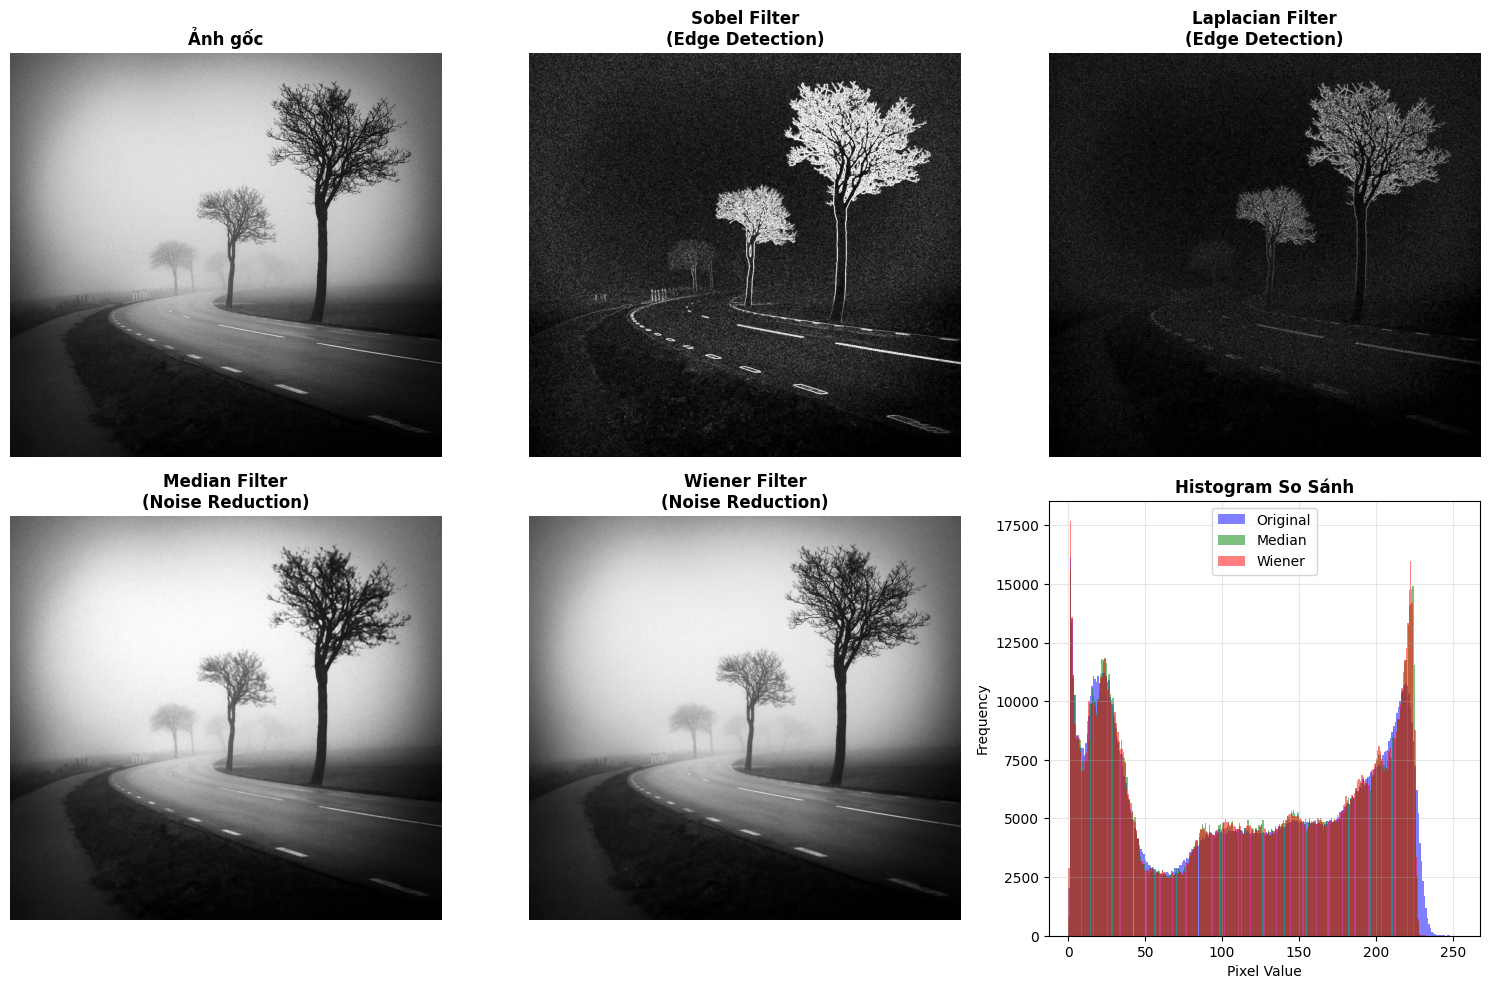

In [8]:
print("\n1. Áp dụng Sobel Filter...")
sobel_result = sobel_filter(img)
print("2. Áp dụng Laplacian Filter...")
laplacian_result = laplacian_filter(img)
print("3. Áp dụng Median Filter...")
median_result = median_filter(img, kernel_size=5)
print("4. Áp dụng Wiener Filter...")
wiener_result = wiener_filter(img, kernel_size=5)
print("\nHoàn thành! Đang hiển thị kết quả...")
# Hiển thị kết quả
plt.figure(figsize=(15, 10))
# Ảnh gốc
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Ảnh gốc', fontsize=12, fontweight='bold')
plt.axis('off')
# Sobel
plt.subplot(2, 3, 2)
plt.imshow(sobel_result, cmap='gray')
plt.title('Sobel Filter\n(Edge Detection)', fontsize=12, fontweight='bold')
plt.axis('off')
# Laplacian
plt.subplot(2, 3, 3)
plt.imshow(laplacian_result, cmap='gray')
plt.title('Laplacian Filter\n(Edge Detection)', fontsize=12, fontweight='bold')
plt.axis('off')
# Median
plt.subplot(2, 3, 4)
plt.imshow(median_result, cmap='gray')
plt.title('Median Filter\n(Noise Reduction)', fontsize=12, fontweight='bold')
plt.axis('off')
# Wiener
plt.subplot(2, 3, 5)
plt.imshow(wiener_result, cmap='gray')
plt.title('Wiener Filter\n(Noise Reduction)', fontsize=12, fontweight='bold')
plt.axis('off')
# Histogram comparison
plt.subplot(2, 3, 6)
plt.hist(img.ravel(), bins=256, alpha=0.5, label='Original', color='blue')
plt.hist(median_result.ravel(), bins=256, alpha=0.5, label='Median', color='green')
plt.hist(wiener_result.ravel(), bins=256, alpha=0.5, label='Wiener', color='red')
plt.title('Histogram So Sánh', fontsize=12, fontweight='bold')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

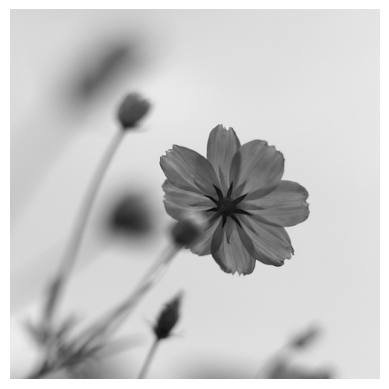

In [13]:
img2 = cv2.imread('flower.jpg',cv2.COLOR_BGR2GRAY)
plt.imshow(img2)
plt.axis('off')
plt.show()

In [29]:
def canny(img,low_threshold = 50, high_threshold = 150, kernel_size = 3, sigma = 1.4):
    blurred = cv2.GaussianBlur(img,(kernel_size,kernel_size),sigma)

    Gx = cv2.Sobel(blurred,cv2.CV_64F,1,0,ksize=3)
    Gy = cv2.Sobel(blurred,cv2.CV_64F,0,1,ksize=3)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    angle = np.arctan2(Gx, Gy)* 180/np.pi
    angle[angle<180] +=180

    rows, cols = magnitude.shape
    suppressed = np.zeros_like(magnitude)

    for i in range(1,rows-1):
        for j in range(1,cols-1):
            theta = angle[i,j]

            if (0<=theta<22.5) or (157.5 <= theta <= 180):
                n1,n2 = magnitude[i,j+1], magnitude[i,j-1]
            elif 22.5  <= theta < 67.5:
                n1, n2 = magnitude[i+1, j-1], magnitude[i-1, j+1]   # 45°
            elif 67.5  <= theta < 112.5:
                n1, n2 = magnitude[i+1, j],   magnitude[i-1, j]     # 90°
            else:
                n1, n2 = magnitude[i-1, j-1], magnitude[i+1, j+1]  # 135°

            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                suppressed[i, j] = magnitude[i, j]
    STRONG, WEAK = 255, 75
    result = np.zeros_like(suppressed, dtype=np.uint8)
    result[suppressed >= high_threshold] = STRONG
    result[(suppressed >= low_threshold) & (suppressed < high_threshold)] = WEAK

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if result[i, j] == WEAK:
                if STRONG in result[i-1:i+2, j-1:j+2]:
                    result[i, j] = STRONG
                else:
                    result[i, j] = 0   # loại bỏ
    return result


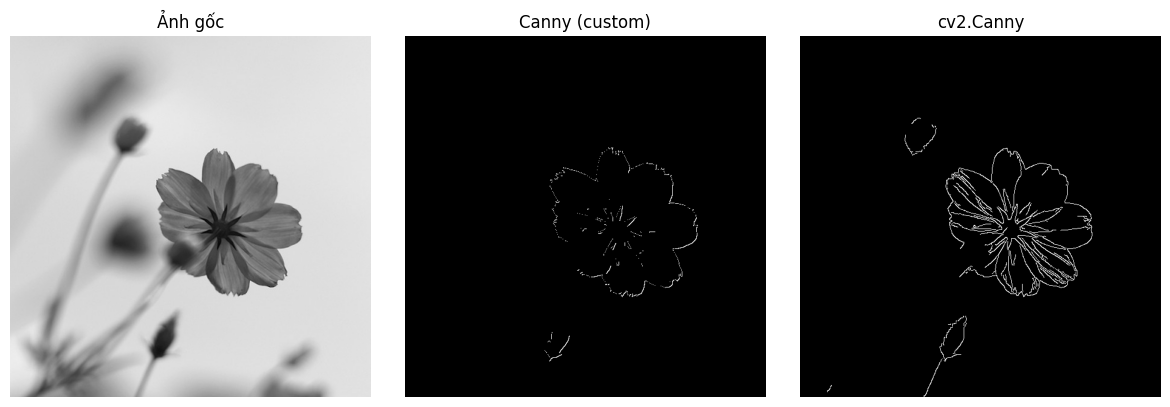

In [30]:
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
canny_custom = canny(img2_gray, low_threshold = 50, high_threshold = 150)
canny_builtin = cv2.Canny(img2_gray, 50, 150)   # so sánh với built-in
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img2, cmap='gray');          plt.title('Ảnh gốc');     plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(canny_custom, cmap='gray'); plt.title('Canny (custom)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(canny_builtin, cmap='gray');plt.title('cv2.Canny');   plt.axis('off')
plt.tight_layout(); plt.show()